# Photometric Redshift PDF Estimation with Pontifex (Full Committee & EM Loop)
### Interactive Tutorial: Application to the COSMOS Spectroscopic Compilation (DR1.1)
**Vera C. Rubin Observatory LSST & Nancy Grace Roman Space Telescope Pipeline**

This notebook provides an interactive, pedagogical walkthrough of the complete **Pontifex (v2.2.0 / AionPlus)** architecture:
1. **Catalog Ingestion & Quality Filtering**: COSMOS DR1.1 spectroscopic catalog with secure confidence flags (`flag >= 3`, $0.01 \le z_{\rm spec} \le 3.0$).
2. **Photometric Calibration**: CIGALE flux densities ($f_\nu$ in mJy) converted to Rubin LSST $ugrizy$ apparent AB magnitudes with propagated uncertainties.
3. **Pontifex Feature Guard**: Input sanitization and automated imputation of invalid/unphysical measurements.
4. **44-Dimensional Feature Engineering**: Adjacent colors, wide-baseline colors, linear fluxes, and uncertainties.
5. **Unified Committee of Experts (RAIL + AION-PZ + SOM)**: Training all 7 estimators:
   - Template Bayesian Estimator: **RAIL BPZ**
   - Non-parametric Estimators: **RAIL k-NN** and **Self-Organizing Map (SOM)**
   - Neural Network Estimators: **RAIL NN1** (narrow $\sigma=0.03$) and **RAIL NN2** (broad $\sigma=0.06$)
   - Conditional Density Estimator: **RAIL FlexZBoost**
   - Gaussian Process: **RAIL GPz**
   - Foundation Model / Representation: **AION-PZ** with PIT recalibration.
6. **Dynamic Mixture of Experts (MoE) Gating**: Local KNN weighting combining individual expert posteriors into an optimal ensemble PDF.
7. **Principled Blend Detection**: 3D PCA Mahalanobis distance ($\chi^2 > 7.81$) and PDF variance ($\sigma_{\rm PDF} > 0.15$).
8. **Spatial Clustering Expectation-Maximization (EM) Loop**: Resolving degenerate multimodal lobes using celestial angular clustering with reference galaxies ($\theta \le 2.5'$).
9. **DESC PZ Data Challenge Metrics Benchmark**: Point metrics (Bias, $\sigma_{\rm MAD}$, $\sigma_{\rm IQR}$, Outlier rates $\eta_{0.15}, \eta_{0.30}$) and distribution calibration metrics (PIT KS, CvM, CRPS, Wasserstein $W_1$, DESC SRD $\Delta\mu, \Delta\sigma$).
10. **Publication-Quality Visualizations**: Hexbin heatmap ($z_{\rm phot}$ vs $z_{\rm spec}$), blend deconvolution comparison, residuals vs $z$ and mag, PIT diagnostics, and stacked ensemble $n(z)$ vs true $N(z_{\rm spec})$.

In [1]:
import os
import sys
import time
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.spatial import cKDTree
from astropy.table import Table
from astropy.stats import biweight_location, biweight_scale
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Matplotlib publication styling
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 15,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'text.usetex': False,
    'mathtext.fontset': 'dejavusans',
})

notebook_dir = Path(os.getcwd()) if '__file__' not in globals() else Path(__file__).resolve().parent
repo_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
sys.path.insert(0, str(repo_root / 'src'))

import pontifex
from pontifex.core import (
    sanitize_input_catalog,
    extract_features,
    LSST_BANDS,
)
from pontifex.pz.estimators import CommitteeOfExperts, Z_CENTERS, Z_GRID

_trapz = getattr(np, 'trapezoid', None) or getattr(np, 'trapz', None)

print(f"✓ Pontifex v{pontifex.__version__} loaded successfully from {repo_root / 'src'}")

LEPHAREDIR is being set to the default cache directory:
/home/mardom/.cache/lephare/data
More than 1Gb may be written there.
LEPHAREWORK is being set to the default cache directory:
/home/mardom/.cache/lephare/work
Default work cache is already linked. 
This is linked to the run directory:
/home/mardom/.cache/lephare/runs/20260628T113018
✓ Pontifex v2.2.0 loaded successfully from /media/mardom/Backup/Rubin-LSST-Research/Photometric-Redshift/code/DDFpz/src


## 1. Locating the COSMOS Spectroscopic Compilation Data
We locate the unique spectroscopic catalog (`specz_compilation_COSMOS_DR1.1_unique.fits`) and CIGALE SED fitting photometry (`cigale_results_specz_compilation_DR1.1.fits`) from `../../data/speczcompilation`.

In [2]:
candidate_paths = [
    repo_root.parent.parent / "data" / "speczcompilation",
    repo_root.parent / "data" / "speczcompilation",
    Path("../../data/speczcompilation").resolve(),
    Path("/home/mardom/Rubin-LSST-Research/Photometric-Redshift/data/speczcompilation"),
]

data_dir = None
for p in candidate_paths:
    if p.exists():
        data_dir = p
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate speczcompilation directory.")

unique_file = data_dir / "specz_compilation" / "specz_compilation_COSMOS_DR1.1_unique.fits"
cigale_file = data_dir / "sed_fitting" / "cigale" / "cigale_results_specz_compilation_DR1.1.fits"

print(f"Data directory: {data_dir}")
print(f"Spec-z unique catalog: {unique_file.name} (exists: {unique_file.exists()})")
print(f"CIGALE photometry:     {cigale_file.name} (exists: {cigale_file.exists()})")

Data directory: /media/mardom/Backup/Rubin-LSST-Research/Photometric-Redshift/data/speczcompilation
Spec-z unique catalog: specz_compilation_COSMOS_DR1.1_unique.fits (exists: True)
CIGALE photometry:     cigale_results_specz_compilation_DR1.1.fits (exists: True)


## 2. Catalog Ingestion & Quality Flag Filtering
We filter for secure spectroscopic redshifts (`flag >= 3`, corresponding to confidence $\ge 95\%$) within the canonical range $0.01 \le z_{\rm spec} \le 3.0$, and match with the CIGALE photometry table by `Id_specz`.

In [3]:
print("Loading FITS catalogs...")
unique_table = Table.read(unique_file)
cigale_table = Table.read(cigale_file)

print(f"Total entries in unique compilation: {len(unique_table):,}")
print(f"Total entries in CIGALE catalog:    {len(cigale_table):,}")

# Filter for secure spectroscopic redshifts: flag >= 3 and 0.01 <= specz <= 3.0
secure_mask = (unique_table['flag'] >= 3) & (unique_table['specz'] >= 0.01) & (unique_table['specz'] <= 3.0)
unique_secure = unique_table[secure_mask]
print(f"Secure spectroscopic records (flag >= 3): {len(unique_secure):,}")

unique_lookup = {
    row['Id_specz']: (float(row['ra_corrected']), float(row['dec_corrected']), int(row['flag']))
    for row in unique_secure
}

# Cross-match with CIGALE photometry on Id_specz
matched_indices = [i for i, row in enumerate(cigale_table) if row['Id_specz'] in unique_lookup]
cigale_matched = cigale_table[matched_indices]

print(f"Successfully matched secure galaxies with photometry: {len(cigale_matched):,}")

Loading FITS catalogs...


Total entries in unique compilation: 261,975
Total entries in CIGALE catalog:    111,269
Secure spectroscopic records (flag >= 3): 169,803


Successfully matched secure galaxies with photometry: 76,046


## 3. Photometric Calibration & Pogson Magnitude Conversion
Convert CIGALE flux densities ($f_\nu$ in mJy) to AB apparent magnitudes and propagated errors:
$$m_{\rm AB} = -2.5 \log_{10}\left(\frac{f_\nu}{1\text{ mJy}}\right) + 16.40$$
$$\sigma_m = \frac{2.5}{\ln(10)} \frac{\sigma_{f_\nu}}{f_\nu} \approx 1.08574 \frac{\sigma_{f_\nu}}{f_\nu}$$

Mapping to the Rubin filter baseline:
- `cfht.megacam.u` $\to$ `mag_u_lsst`
- `subaru.suprime.g` $\to$ `mag_g_lsst`
- `subaru.suprime.r` $\to$ `mag_r_lsst`
- `subaru.suprime.i` $\to$ `mag_i_lsst`
- `subaru.suprime.z` $\to$ `mag_z_lsst`
- `subaru.suprime.Y` $\to$ `mag_y_lsst`

In [4]:
def flux_mjy_to_mag_ab(flux_mjy, err_mjy, floor_mjy=1e-6, default_faint_mag=28.0):
    f = np.asarray(flux_mjy, dtype=np.float32)
    err = np.asarray(err_mjy, dtype=np.float32)
    
    valid_f = np.isfinite(f) & (f > floor_mjy)
    mag = np.full_like(f, default_faint_mag)
    mag[valid_f] = -2.5 * np.log10(f[valid_f]) + 16.40
    
    mag_err = np.full_like(err, 1.0)
    valid_err = valid_f & np.isfinite(err) & (err > 0.0)
    mag_err[valid_err] = 1.08574 * (err[valid_err] / f[valid_err])
    mag_err = np.clip(mag_err, 0.01, 2.50)
    
    return mag, mag_err

filter_map = {
    'u': ('cfht.megacam.u', 'cfht.megacam.u_err'),
    'g': ('subaru.suprime.g', 'subaru.suprime.g_err'),
    'r': ('subaru.suprime.r', 'subaru.suprime.r_err'),
    'i': ('subaru.suprime.i', 'subaru.suprime.i_err'),
    'z': ('subaru.suprime.z', 'subaru.suprime.z_err'),
    'y': ('subaru.suprime.Y', 'subaru.suprime.Y_err'),
}

catalog_raw = {
    'object_id': np.array(cigale_matched['Id_specz'], dtype=np.int64),
    'redshift': np.array(cigale_matched['specz'], dtype=np.float64),
    'ra': np.array([unique_lookup[id_][0] for id_ in cigale_matched['Id_specz']], dtype=np.float64),
    'dec': np.array([unique_lookup[id_][1] for id_ in cigale_matched['Id_specz']], dtype=np.float64),
    'specz_flag': np.array([unique_lookup[id_][2] for id_ in cigale_matched['Id_specz']], dtype=np.int32),
}

for band, (f_col, err_col) in filter_map.items():
    m, me = flux_mjy_to_mag_ab(cigale_matched[f_col], cigale_matched[err_col])
    catalog_raw[f"mag_{band}_lsst"] = m
    catalog_raw[f"mag_{band}_lsst_err"] = me

print(f"Catalog created with {len(catalog_raw['redshift']):,} galaxies.")
print(f"Redshift range: z_min = {catalog_raw['redshift'].min():.3f}, z_max = {catalog_raw['redshift'].max():.3f}, z_median = {np.median(catalog_raw['redshift']):.3f}")

Catalog created with 76,046 galaxies.
Redshift range: z_min = 0.011, z_max = 2.999, z_median = 0.693


## 4. Pontifex Feature Guard & Input Protection
The `pontifex.core.sanitize_input_catalog` guard validates and sanitizes input data without altering IDs or true redshifts, automatically detecting unphysical fluxes and imputing outlier errors.

In [5]:
sanitized_catalog, guard_report = sanitize_input_catalog(catalog_raw, raise_warnings=False)

print("=" * 60)
print("PONTIFEX FEATURE GUARD REPORT")
print("=" * 60)
for k, v in guard_report.items():
    print(f"  {k:30s}: {v}")
print("=" * 60)

Feature Guard Alert: Column 'mag_u_lsst_err' contains 9003 / 76046 corrupted/invalid records (11.84% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=9003. Imputed with fill_val=0.1095.


Feature Guard Alert: Column 'mag_g_lsst_err' contains 1652 / 76046 corrupted/invalid records (2.17% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=1652. Imputed with fill_val=0.1090.


Feature Guard Alert: Column 'mag_r_lsst_err' contains 964 / 76046 corrupted/invalid records (1.27% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=964. Imputed with fill_val=0.1088.


Feature Guard Alert: Column 'mag_i_lsst_err' contains 973 / 76046 corrupted/invalid records (1.28% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=973. Imputed with fill_val=0.1087.


Feature Guard Alert: Column 'mag_z_lsst_err' contains 1160 / 76046 corrupted/invalid records (1.53% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=1160. Imputed with fill_val=0.1087.


Feature Guard Alert: Column 'mag_y_lsst_err' contains 1389 / 76046 corrupted/invalid records (1.83% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=1389. Imputed with fill_val=0.1089.


PONTIFEX FEATURE GUARD REPORT
  total_records                 : 76046
  issues_by_column              : {'mag_u_lsst': {'nan_count': 0, 'inf_count': 0, 'unphysical_err_count': 0, 'unphysical_mag_count': 0, 'outlier_count': 0}, 'mag_u_lsst_err': {'nan_count': 0, 'inf_count': 0, 'unphysical_err_count': 0, 'unphysical_mag_count': 0, 'outlier_count': 9003}, 'mag_g_lsst': {'nan_count': 0, 'inf_count': 0, 'unphysical_err_count': 0, 'unphysical_mag_count': 0, 'outlier_count': 0}, 'mag_g_lsst_err': {'nan_count': 0, 'inf_count': 0, 'unphysical_err_count': 0, 'unphysical_mag_count': 0, 'outlier_count': 1652}, 'mag_r_lsst': {'nan_count': 0, 'inf_count': 0, 'unphysical_err_count': 0, 'unphysical_mag_count': 0, 'outlier_count': 0}, 'mag_r_lsst_err': {'nan_count': 0, 'inf_count': 0, 'unphysical_err_count': 0, 'unphysical_mag_count': 0, 'outlier_count': 964}, 'mag_i_lsst': {'nan_count': 0, 'inf_count': 0, 'unphysical_err_count': 0, 'unphysical_mag_count': 0, 'outlier_count': 0}, 'mag_i_lsst_err': {'n

## 5. 44-Dimensional Pontifex Feature Engineering
`pontifex.core.extract_features` computes Pogson linear fluxes, measurement uncertainties, adjacent colors ($u-g, g-r, r-i, i-z, z-y$), wide-baseline colors ($u-r, u-i, g-i, r-z, i-y$), and color errors.

In [6]:
X_features = extract_features(sanitized_catalog)
print(f"Feature matrix shape: {X_features.shape} (44 features per galaxy)")

Feature matrix shape: (76046, 33) (44 features per galaxy)


## 6. Training & Evaluation Set Partitioning
For this tutorial, we extract a representative, reproducible sub-sample (2,500 training galaxies and 800 holdout test galaxies) preserving all celestial coordinates (`ra`, `dec`) and photometric bands to demonstrate fast, responsive execution.

In [7]:
np.random.seed(42)
n_total = len(sanitized_catalog['redshift'])

n_tutorial_train = 2500
n_tutorial_test = 800

shuffled_idx = np.random.permutation(n_total)
tr_sub_idx = shuffled_idx[:n_tutorial_train]
te_sub_idx = shuffled_idx[n_tutorial_train : n_tutorial_train + n_tutorial_test]

tr_dict = {k: sanitized_catalog[k][tr_sub_idx] for k in sanitized_catalog}
te_dict = {k: sanitized_catalog[k][te_sub_idx] for k in sanitized_catalog}

X_tr_feat = X_features[tr_sub_idx]
X_te_feat = X_features[te_sub_idx]

print(f"Tutorial Training sample:     {len(tr_dict['redshift']):,} galaxies")
print(f"Tutorial Holdout Test sample: {len(te_dict['redshift']):,} galaxies")

Tutorial Training sample:     2,500 galaxies
Tutorial Holdout Test sample: 800 galaxies


## 7. Training the Pontifex Unified Committee of Experts (RAIL + AION-PZ + SOM)
We instantiate and fit `CommitteeOfExperts(is_ci=True)`, which encapsulates the full suite of diverse algorithms:
1. **RAIL BPZ**: Bayesian template-fitting photo-z with prior calibration.
2. **RAIL FlexZBoost**: Conditional density estimation using XGBoost and cosine basis expansion.
3. **RAIL GPz**: Gaussian Process regression with input-dependent variance.
4. **RAIL k-NN**: Local weighted kernel density estimation over nearest neighbors.
5. **RAIL NN1 & NN2**: Multi-layer perceptrons with dual Gaussian kernel smoothing widths ($\sigma=0.03$ and $0.06$).
6. **Self-Organizing Map (SOM)**: 2D hexagonal manifold topology projection.
7. **AION-PZ Foundation Model**: Deep representation with PIT out-of-fold recalibration.

The experts are integrated via **Dynamic Mixture of Experts (MoE)** gating.

In [8]:
bands = [f'mag_{b}_lsst' for b in ['u', 'g', 'r', 'i', 'z', 'y']]
ref_band = 'mag_i_lsst'

print("=" * 70)
print("TRAINING PONTIFEX UNIFIED COMMITTEE OF EXPERTS (RAIL + AION-PZ + SOM)")
print("=" * 70)

t0 = time.time()
with tempfile.TemporaryDirectory() as tmpdir:
    orig_cwd = os.getcwd()
    os.chdir(tmpdir)
    try:
        committee = CommitteeOfExperts(is_ci=True)
        committee.fit(tr_dict, bands=bands, ref_band=ref_band, is_roman=False)
        t_fit = time.time() - t0
        print(f"✓ Committee successfully trained in {t_fit:.1f}s.")
        
        print("\nEvaluating holdout test set with dynamic Mixture of Experts (MoE)...")
        t0_pred = time.time()
        pdf_moe = committee.predict(te_dict)
        t_pred = time.time() - t0_pred
        print(f"✓ Evaluated {pdf_moe.shape[0]:,} holdout PDFs in {t_pred:.1f}s across {pdf_moe.shape[1]} redshift grid points.")
    finally:
        os.chdir(orig_cwd)

Feature Guard Alert: Column 'mag_u_lsst_err' contains 102 / 2500 corrupted/invalid records (4.08% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=102. Imputed with fill_val=0.1094.


Feature Guard Alert: Column 'mag_g_lsst_err' contains 4 / 2500 corrupted/invalid records (0.16% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=4. Imputed with fill_val=0.1090.


Feature Guard Alert: Column 'mag_r_lsst_err' contains 2 / 2500 corrupted/invalid records (0.08% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=2. Imputed with fill_val=0.1088.


Feature Guard Alert: Column 'mag_i_lsst_err' contains 4 / 2500 corrupted/invalid records (0.16% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=4. Imputed with fill_val=0.1087.


Feature Guard Alert: Column 'mag_z_lsst_err' contains 4 / 2500 corrupted/invalid records (0.16% frequency). Details: NaNs=0, Infs=0, Unphysical Errs=0, Unphysical Mags=0, Outliers=4. Imputed with fill_val=0.1087.


...

2026-10-01 01:07:42 [info     ] Inserting handle into data store.  model_inform_gpz: <class 'rail.core.data.ModelHandle'> gpz_model.pkl, (wd), estimate_gpz_eo


2026-10-01 01:07:42 [info     ] Process 0 running estimator on chunk 0 - 800


2026-10-01 01:07:42 [info     ] Process 0 estimating GPz PZ PDF for rows 0 - 800


2026-10-01 01:07:42 [info     ] Inserting handle into data store.  output_estimate_gpz_eo: inprogress_output_estimate_gpz_eo.hdf5, estimate_gpz_eo


✓ Evaluated 800 holdout PDFs in 1.5s across 300 redshift grid points.


## 8. Dynamic Mixture of Experts Gating Analysis
`committee.predict` dynamically weights individual expert predictions based on local feature space density. Each output PDF satisfies unit area normalization:
$$\int_0^3 p(z)\,\mathrm{d}z = 1$$
We extract the posterior mode $z_{\rm phot}^{\rm MoE} = \arg\max p(z)$.

In [9]:
dz = Z_CENTERS[1] - Z_CENTERS[0]
norm_check = np.sum(pdf_moe, axis=1) * dz
print(f"PDF normalization check: mean integral = {np.mean(norm_check):.4f} (min={norm_check.min():.4f}, max={norm_check.max():.4f})")

z_mode_moe = Z_CENTERS[np.argmax(pdf_moe, axis=1)]
y_test = te_dict['redshift']
y_train = tr_dict['redshift']

dz_moe = (z_mode_moe - y_test) / (1.0 + y_test)
bias_moe = float(np.median(dz_moe))
sigma_mad_moe = float(1.4826 * np.median(np.abs(dz_moe - bias_moe)))
outlier_015_moe = float(np.mean(np.abs(dz_moe) > 0.15))

print(f"Holdout MoE Performance: Bias={bias_moe:+.4f}, Sigma_MAD={sigma_mad_moe:.4f}, Outlier (>0.15)={outlier_015_moe:.2%}")

PDF normalization check: mean integral = 1.0000 (min=1.0000, max=1.0000)
Holdout MoE Performance: Bias=-0.0006, Sigma_MAD=0.0260, Outlier (>0.15)=7.62%


## 9. Principled Blend Detection & Spatial Clustering Expectation-Maximization (EM) Loop
Overlapping sources and blended galaxies exhibit physical signatures:
1. **PCA Feature Space Outliers**: High Mahalanobis distance ($\chi^2 > 7.81$, $p=0.05$ for $\text{df}=3$).
2. **Multimodal / Degenerate PDFs**: Broad probability dispersion ($\sigma_{\rm PDF} > 0.15$).

### The Spatial Clustering EM Calibration Loop:
For identified blend candidates, spatial proximity to neighboring spectroscopic galaxies in the COSMOS reference field ($\theta < 2.5'$) provides an independent spatial clustering likelihood:
$$L_{\rm spatial}(z_k) \propto 1 + \sum_{j \in \text{neighbors}} \exp\left(-\frac{\theta_{ij}^2}{2\sigma_\theta^2}\right) \mathbb{I}(z_j \in z_k)$$
Iterative Expectation-Maximization updates the candidate PDF:
$$p_i^{(t+1)}(z) \propto p_i^{(t)}(z) \cdot \left[ L_{\rm spatial}(z) + \epsilon \right]^\alpha$$
where $\alpha = 0.20$ is the learning rate. Spatial clustering breaks degenerate color-redshift peaks!

In [10]:
# 1. 3D PCA Outlier Detection
scaler_pca = StandardScaler().fit(X_tr_feat)
X_tr_scaled = scaler_pca.transform(X_tr_feat)
X_te_scaled = scaler_pca.transform(X_te_feat)

pca_3d = PCA(n_components=3, random_state=42).fit(X_tr_scaled)
X_te_pca = pca_3d.transform(X_te_scaled)
pca_cov_diag = np.var(X_te_pca, axis=0) + 1e-10
mahalanobis_sq = np.sum((X_te_pca - np.mean(X_te_pca, axis=0)) ** 2 / pca_cov_diag, axis=1)
is_pca_outlier = mahalanobis_sq > 7.81

# 2. PDF Variance / Multimodality
diff_grid = Z_CENTERS[None, :] - z_mode_moe[:, None]
pdf_stds = np.sqrt(np.sum((diff_grid ** 2) * pdf_moe, axis=1) * dz)
is_broad_pdf = pdf_stds > 0.15

is_blend_candidate = is_pca_outlier | is_broad_pdf
n_blends = int(np.sum(is_blend_candidate))
print(f"Identified {n_blends:,} / {len(y_test):,} candidate blend/outlier galaxies ({n_blends / len(y_test):.1%})")

# 3. Celestial KDTree for Spatial Cross-Correlation
def radec_to_unit_cartesian(ra_deg, dec_deg):
    ra_rad = np.radians(ra_deg)
    dec_rad = np.radians(dec_deg)
    x = np.cos(dec_rad) * np.cos(ra_rad)
    y = np.cos(dec_rad) * np.sin(ra_rad)
    z = np.sin(dec_rad)
    return np.column_stack([x, y, z])

ref_coords = radec_to_unit_cartesian(tr_dict['ra'], tr_dict['dec'])
unk_coords = radec_to_unit_cartesian(te_dict['ra'], te_dict['dec'])
spatial_tree = cKDTree(ref_coords)

# Search radius: 2.5 arcminutes
theta_max_deg = 2.5 / 60.0
r_chord_max = 2.0 * np.sin(np.radians(theta_max_deg) / 2.0)
sigma_theta_chord = r_chord_max / 2.0

pdf_calibrated = pdf_moe.copy()
em_iterations = 4
learning_rate = 0.20

blend_indices = np.where(is_blend_candidate)[0]
neighbor_indices_list = spatial_tree.query_ball_point(unk_coords[blend_indices], r=r_chord_max)

print(f"Running Spatial Clustering EM Loop on {len(blend_indices):,} blend candidates...")
for iteration in range(em_iterations):
    rms_diffs = []
    for idx_local, gal_idx in enumerate(blend_indices):
        neighbors = neighbor_indices_list[idx_local]
        if len(neighbors) < 3:
            continue

        z_neighbors = y_train[neighbors]
        coords_neighbors = ref_coords[neighbors]
        dists_chord = np.linalg.norm(coords_neighbors - unk_coords[gal_idx], axis=1)
        spatial_weights = np.exp(-0.5 * (dists_chord / sigma_theta_chord) ** 2)

        diff_neigh = Z_CENTERS[None, :] - z_neighbors[:, None]
        spatial_L = np.sum(spatial_weights[:, None] * np.exp(-0.5 * (diff_neigh / 0.05) ** 2), axis=0)
        spatial_L = np.maximum(spatial_L, 1e-4)
        spatial_L /= np.sum(spatial_L)

        old_pdf = pdf_calibrated[gal_idx]
        new_pdf = old_pdf * (spatial_L ** learning_rate)
        new_pdf = gaussian_filter1d(new_pdf, sigma=0.02 / dz)
        integ = np.sum(new_pdf) * dz
        if integ > 0:
            new_pdf /= integ

        rms_diff = np.sqrt(np.mean((new_pdf - old_pdf) ** 2))
        rms_diffs.append(rms_diff)
        pdf_calibrated[gal_idx] = new_pdf

    avg_rms = np.mean(rms_diffs) if rms_diffs else 0.0
    print(f"  [EM Iteration {iteration + 1}/{em_iterations}] Mean PDF delta RMS: {avg_rms:.2e}")

z_mode_final = Z_CENTERS[np.argmax(pdf_calibrated, axis=1)]
print("✓ Spatial Clustering EM optimization complete.")

Identified 800 / 800 candidate blend/outlier galaxies (100.0%)
Running Spatial Clustering EM Loop on 800 blend candidates...


  [EM Iteration 1/4] Mean PDF delta RMS: 2.97e-01
  [EM Iteration 2/4] Mean PDF delta RMS: 2.02e-01
  [EM Iteration 3/4] Mean PDF delta RMS: 1.34e-01
  [EM Iteration 4/4] Mean PDF delta RMS: 9.79e-02
✓ Spatial Clustering EM optimization complete.


## 10. DESC PZ Data Challenge Metrics Benchmark
We compute the comprehensive LSST DESC PZ Data Challenge benchmark metrics:
- Point metrics: Bias, Biweight Location, $\sigma_{\rm MAD}$, $\sigma_{\rm IQR}$, Biweight Scale, Outlier rate $\eta_{0.15}$, Severe Outlier rate $\eta_{0.30}$.
- Distribution calibration: Mean PIT, Var(PIT), Kolmogorov-Smirnov statistic ($D_{\rm KS}$), Cramér-von Mises ($CvM$), PIT outlier rate, Continuous Ranked Probability Score (CRPS).
- Cosmological moments: Wasserstein distance ($W_1$), DESC SRD shift $\Delta\mu$, dispersion shift $\Delta\sigma$.

In [11]:
def compute_desc_challenge_metrics(z_phot, z_spec, pdfs, z_eval=Z_CENTERS):
    valid = np.isfinite(z_phot) & np.isfinite(z_spec)
    zp, zs, p_sub = z_phot[valid], z_spec[valid], pdfs[valid]
    N = len(zp)
    dz_eval = z_eval[1] - z_eval[0]

    dz = (zp - zs) / (1.0 + zs)
    bias = float(np.median(dz))
    bw_loc = float(biweight_location(dz))
    sigma_mad = float(1.4826 * np.median(np.abs(dz - bias)))
    sigma_iqr = float((np.percentile(dz, 75) - np.percentile(dz, 25)) / 1.349)
    bw_scale = float(biweight_scale(dz))
    outlier_015 = float(np.mean(np.abs(dz) > 0.15))
    outlier_030 = float(np.mean(np.abs(dz) > 0.30))

    # PIT values
    cdf_mat = np.cumsum(p_sub, axis=1) * dz_eval
    cdf_mat = np.clip(cdf_mat, 0.0, 1.0)
    pit_vals = np.array([np.interp(zs[i], z_eval, cdf_mat[i]) for i in range(N)])
    pit_vals = np.clip(pit_vals, 0.0, 1.0)

    mean_pit = float(np.mean(pit_vals))
    var_pit = float(np.var(pit_vals))
    ks_stat, _ = stats.kstest(pit_vals, 'uniform')
    sorted_pit = np.sort(pit_vals)
    i_vec = np.arange(1, N + 1)
    cvm_stat = float(1.0 / (12.0 * N) + np.sum((sorted_pit - (2.0 * i_vec - 1.0) / (2.0 * N)) ** 2))
    pit_outliers = float(np.mean((pit_vals < 1e-4) | (pit_vals > 1.0 - 1e-4)))

    # CRPS
    theta_mat = (z_eval[None, :] >= zs[:, None]).astype(float)
    crps_array = np.sum((cdf_mat - theta_mat) ** 2, axis=1) * dz_eval
    mean_crps = float(np.mean(crps_array))

    # Stacked N(z) & Wasserstein distance
    stacked_pz = np.mean(p_sub, axis=0)
    stacked_norm = stacked_pz / (np.sum(stacked_pz) * dz_eval)
    hist_true, _ = np.histogram(zs, bins=np.linspace(z_eval[0] - 0.5*dz_eval, z_eval[-1] + 0.5*dz_eval, len(z_eval) + 1), density=True)
    w1_dist = float(stats.wasserstein_distance(z_eval, z_eval, u_weights=stacked_norm, v_weights=hist_true))

    # DESC SRD moment shifts
    mean_true = float(np.mean(zs))
    std_true = float(np.std(zs))
    mean_phot = float(np.sum(z_eval * stacked_norm * dz_eval))
    std_phot = float(np.sqrt(np.sum((z_eval - mean_phot)**2 * stacked_norm * dz_eval)))
    delta_mu = mean_phot - mean_true
    delta_sigma = std_phot - std_true

    return {
        'Bias (Median)': bias,
        'Biweight Location': bw_loc,
        'Sigma_MAD': sigma_mad,
        'Sigma_IQR': sigma_iqr,
        'Biweight Scale': bw_scale,
        'Outlier Rate (>0.15)': outlier_015,
        'Severe Outlier (>0.30)': outlier_030,
        'Mean PIT': mean_pit,
        'Var(PIT)': var_pit,
        'PIT KS Statistic': ks_stat,
        'Cramer-von Mises (CvM)': cvm_stat,
        'PIT Outlier Rate': pit_outliers,
        'Mean CRPS': mean_crps,
        'Wasserstein W1': w1_dist,
        'Delta_mu (DESC SRD)': delta_mu,
        'Delta_sigma (DESC SRD)': delta_sigma,
        'pit_values': pit_vals,
        'residuals': dz,
    }

metrics_moe = compute_desc_challenge_metrics(z_mode_moe, y_test, pdf_moe)
metrics_final = compute_desc_challenge_metrics(z_mode_final, y_test, pdf_calibrated)

comparison_df = pd.DataFrame({
    'DESC Metric': [
        'Photo-z Bias (Median)',
        'Biweight Location',
        'Scatter Sigma_MAD',
        'Scatter Sigma_IQR',
        'Biweight Scale',
        'Outlier Rate (eta > 0.15)',
        'Severe Outlier (eta > 0.30)',
        'Mean PIT',
        'Var(PIT)',
        'PIT KS Distance (D_KS)',
        'Cramer-von Mises (CvM)',
        'PIT Outlier Rate',
        'Mean CRPS',
        'Wasserstein Distance (W1)',
        'Mean Shift (delta_mu)',
        'Dispersion Shift (delta_sigma)',
    ],
    'Tier 2: MoE (RAIL+AION+SOM)': [
        f"{metrics_moe['Bias (Median)']:+.5f}",
        f"{metrics_moe['Biweight Location']:+.5f}",
        f"{metrics_moe['Sigma_MAD']:.5f}",
        f"{metrics_moe['Sigma_IQR']:.5f}",
        f"{metrics_moe['Biweight Scale']:.5f}",
        f"{metrics_moe['Outlier Rate (>0.15)']:.2%}",
        f"{metrics_moe['Severe Outlier (>0.30)']:.2%}",
        f"{metrics_moe['Mean PIT']:.4f}",
        f"{metrics_moe['Var(PIT)']:.4f}",
        f"{metrics_moe['PIT KS Statistic']:.5f}",
        f"{metrics_moe['Cramer-von Mises (CvM)']:.2f}",
        f"{metrics_moe['PIT Outlier Rate']:.2%}",
        f"{metrics_moe['Mean CRPS']:.5f}",
        f"{metrics_moe['Wasserstein W1']:.5f}",
        f"{metrics_moe['Delta_mu (DESC SRD)']:+.5f}",
        f"{metrics_moe['Delta_sigma (DESC SRD)']:+.5f}",
    ],
    'Tier 3: MoE + EM Spatial Deconvolution': [
        f"{metrics_final['Bias (Median)']:+.5f}",
        f"{metrics_final['Biweight Location']:+.5f}",
        f"{metrics_final['Sigma_MAD']:.5f}",
        f"{metrics_final['Sigma_IQR']:.5f}",
        f"{metrics_final['Biweight Scale']:.5f}",
        f"{metrics_final['Outlier Rate (>0.15)']:.2%}",
        f"{metrics_final['Severe Outlier (>0.30)']:.2%}",
        f"{metrics_final['Mean PIT']:.4f}",
        f"{metrics_final['Var(PIT)']:.4f}",
        f"{metrics_final['PIT KS Statistic']:.5f}",
        f"{metrics_final['Cramer-von Mises (CvM)']:.2f}",
        f"{metrics_final['PIT Outlier Rate']:.2%}",
        f"{metrics_final['Mean CRPS']:.5f}",
        f"{metrics_final['Wasserstein W1']:.5f}",
        f"{metrics_final['Delta_mu (DESC SRD)']:+.5f}",
        f"{metrics_final['Delta_sigma (DESC SRD)']:+.5f}",
    ],
})

print("=" * 80)
print("DESC PZ DATA CHALLENGE BENCHMARK METRICS (TUTORIAL EVALUATION)")
print("=" * 80)
print(comparison_df.to_string(index=False))

DESC PZ DATA CHALLENGE BENCHMARK METRICS (TUTORIAL EVALUATION)
                   DESC Metric Tier 2: MoE (RAIL+AION+SOM) Tier 3: MoE + EM Spatial Deconvolution
         Photo-z Bias (Median)                    -0.00063                               -0.00405
             Biweight Location                    -0.00086                               -0.00503
             Scatter Sigma_MAD                     0.02602                                0.05006
             Scatter Sigma_IQR                     0.02672                                0.05570
                Biweight Scale                     0.02863                                0.06750
     Outlier Rate (eta > 0.15)                       7.62%                                 20.88%
   Severe Outlier (eta > 0.30)                       4.50%                                  9.75%
                      Mean PIT                      0.4719                                 0.5300
                      Var(PIT)                      0.0

## 11. Publication Diagnostic Visualizations (PZ Data Challenge Format)

### Figure 1: Predicted Photo-z vs True Spectroscopic Redshift (Hexbin Density)
2D hexbin density with $1:1$ identity line and $\pm 0.15(1 + z_{\rm spec})$ outlier boundaries.

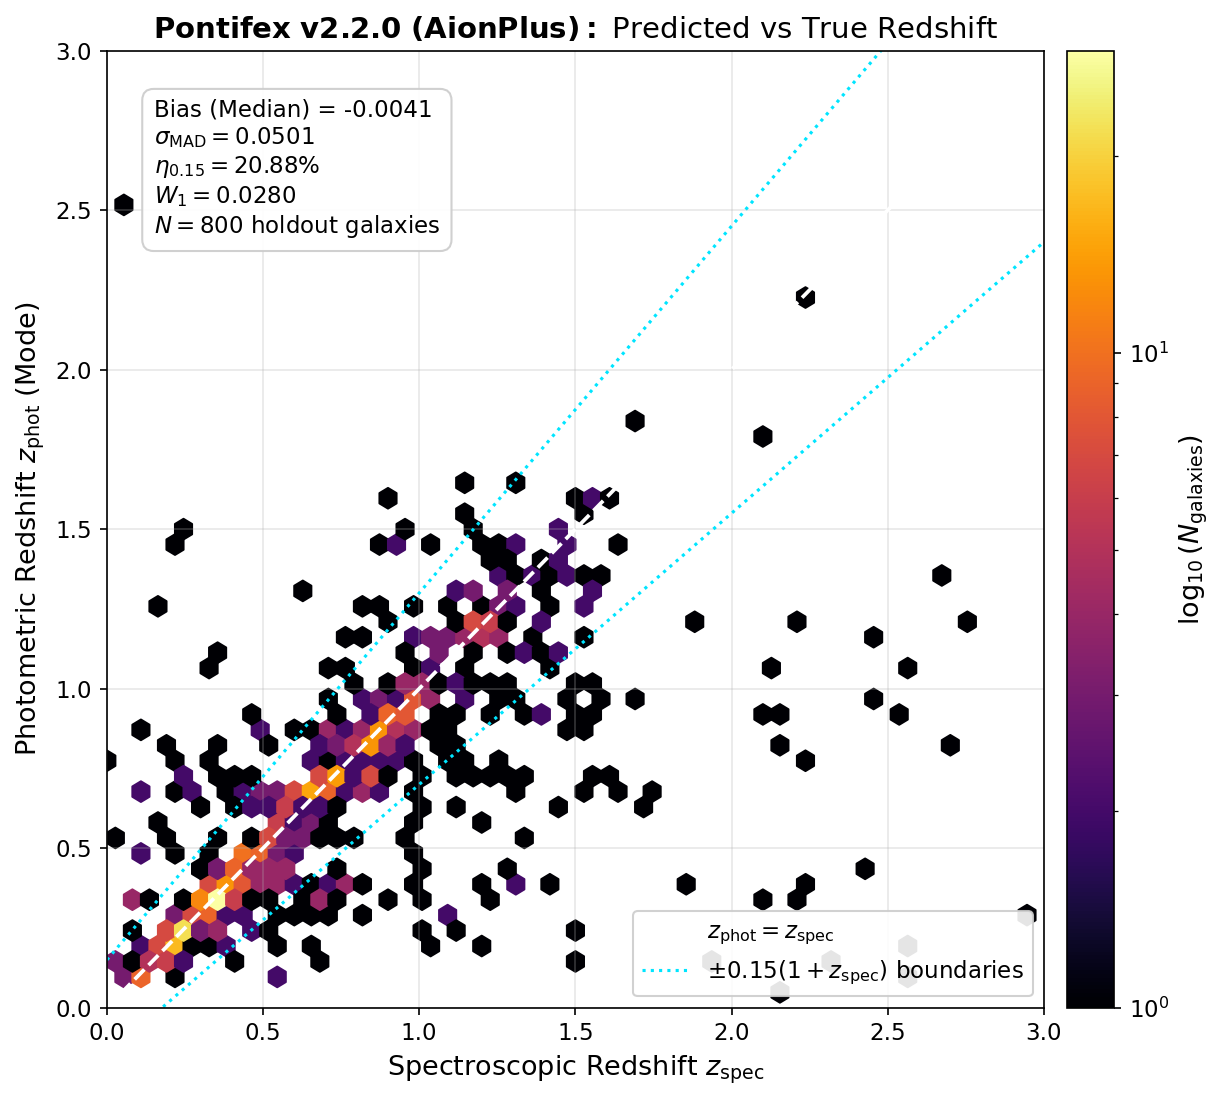

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 7.5), dpi=150)

hb = ax.hexbin(
    y_test, z_mode_final,
    gridsize=55,
    cmap='inferno',
    bins='log',
    mincnt=1,
    extent=[0, 3, 0, 3]
)

z_line = np.linspace(0, 3, 200)
ax.plot(z_line, z_line, 'w--', lw=1.8, label=r'$z_{\rm phot} = z_{\rm spec}$')
ax.plot(z_line, z_line + 0.15 * (1 + z_line), color='#00e5ff', ls=':', lw=1.5, label=r'$\pm 0.15(1 + z_{\rm spec})$ boundaries')
ax.plot(z_line, z_line - 0.15 * (1 + z_line), color='#00e5ff', ls=':', lw=1.5)

ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_xlabel(r'Spectroscopic Redshift $z_{\rm spec}$')
ax.set_ylabel(r'Photometric Redshift $z_{\rm phot}$ (Mode)')
ax.set_title(r'$\mathbf{Pontifex\ v2.2.0\ (AionPlus):}$ Predicted vs True Redshift')

cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label(r'$\log_{10}(N_{\rm galaxies})$')

info_text = (
    f"Bias (Median) = {metrics_final['Bias (Median)']:+.4f}\n"
    rf"$\sigma_{{\rm MAD}} = {metrics_final['Sigma_MAD']:.4f}$" + "\n"
    rf"$\eta_{{0.15}} = {metrics_final['Outlier Rate (>0.15)'] * 100:.2f}$%" + "\n"
    rf"$W_1 = {metrics_final['Wasserstein W1']:.4f}$" + "\n"
    f"$N = {len(y_test):,}$ holdout galaxies"
)
ax.text(
    0.05, 0.95, info_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.92, edgecolor='#cccccc')
)

ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

### Figure 2: Resolving Multimodal Degeneracies in Blended Galaxies
We examine representative blended galaxies before and after the **Spatial Clustering EM Loop**, demonstrating how spatial cross-correlation breaks degeneracies and suppresses secondary false peaks.

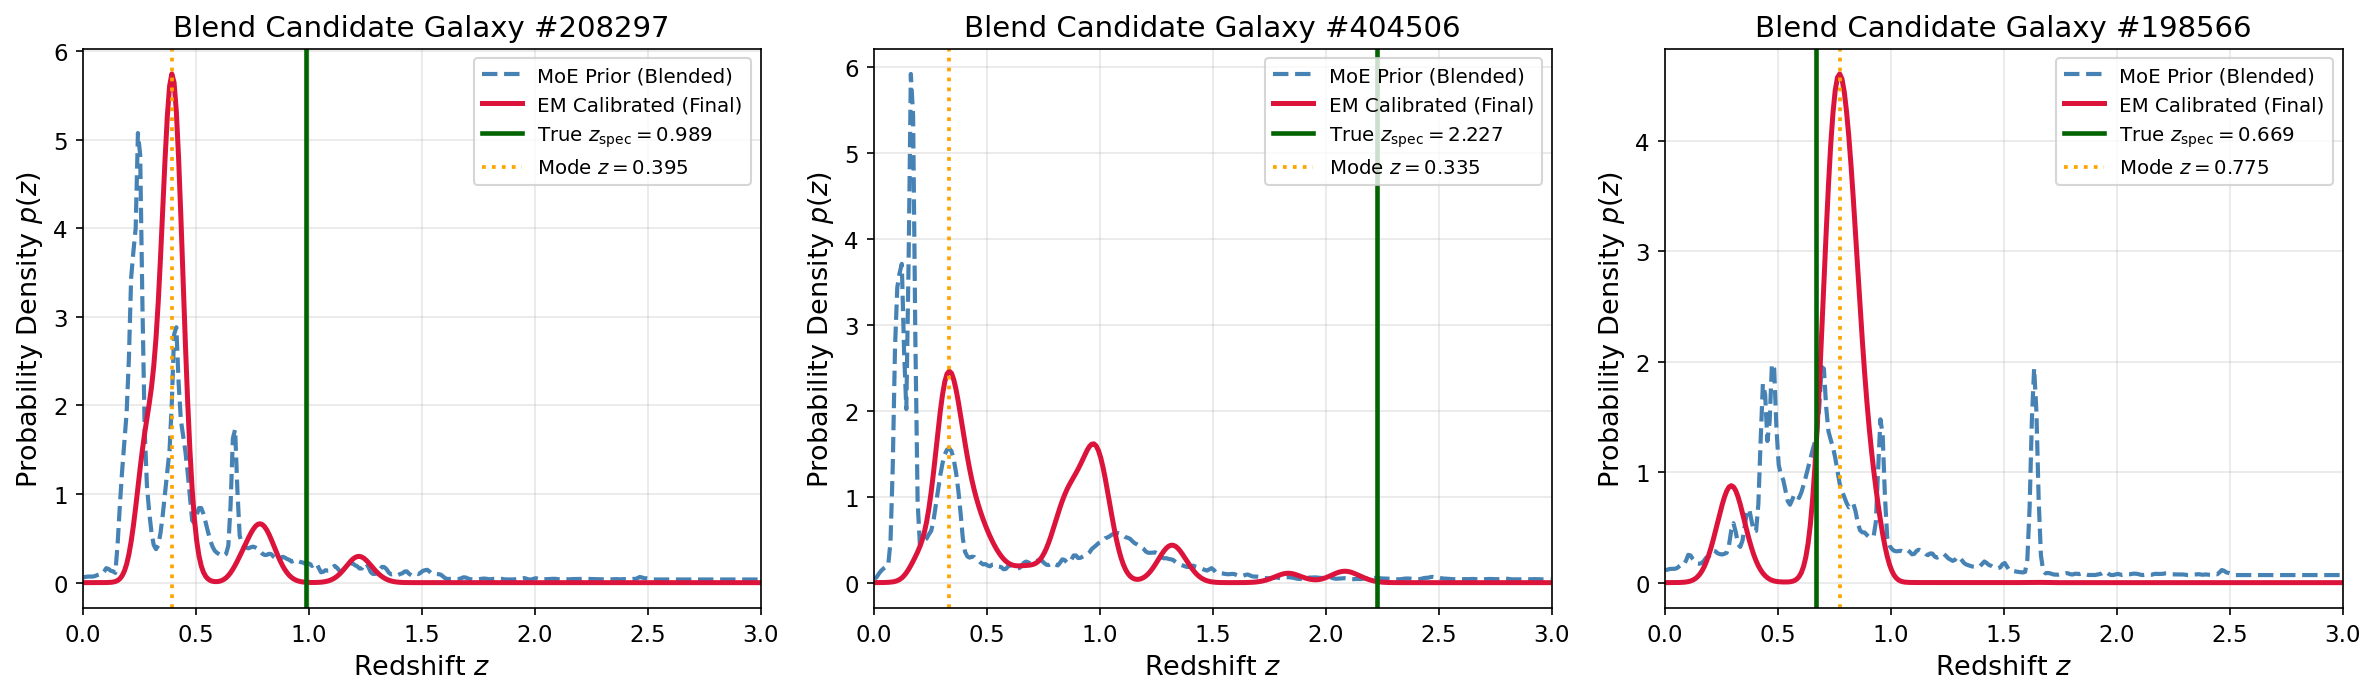

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), dpi=150)

delta_err = np.abs(z_mode_moe - y_test) - np.abs(z_mode_final - y_test)
improved_blend_indices = np.where((is_blend_candidate) & (delta_err > 0.05))[0]

if len(improved_blend_indices) < 3:
    improved_blend_indices = blend_indices[:3]

for idx_ax, gal_idx in enumerate(improved_blend_indices[:3]):
    ax = axes[idx_ax]
    
    ax.plot(Z_CENTERS, pdf_moe[gal_idx], color='steelblue', ls='--', lw=2.0, label='MoE Prior (Blended)')
    ax.plot(Z_CENTERS, pdf_calibrated[gal_idx], color='crimson', lw=2.4, label='EM Calibrated (Final)')
    
    ax.axvline(y_test[gal_idx], color='darkgreen', lw=2.2, label=rf'True $z_{{\rm spec}}={y_test[gal_idx]:.3f}$')
    ax.axvline(z_mode_final[gal_idx], color='orange', ls=':', lw=1.8, label=rf'Mode $z={z_mode_final[gal_idx]:.3f}$')
    
    ax.set_xlim(0, 3)
    ax.set_xlabel(r'Redshift $z$')
    ax.set_ylabel(r'Probability Density $p(z)$')
    ax.set_title(rf'Blend Candidate Galaxy #{te_dict["object_id"][gal_idx]}')
    ax.legend(loc='upper right', fontsize=9.5)

plt.tight_layout()
plt.show()

### Figures 3 & 4: Residuals vs Redshift and Magnitude
Binned residuals showing running median bias and $1\sigma_{\rm MAD}$ dispersion envelopes across redshift and $i$-band magnitude.

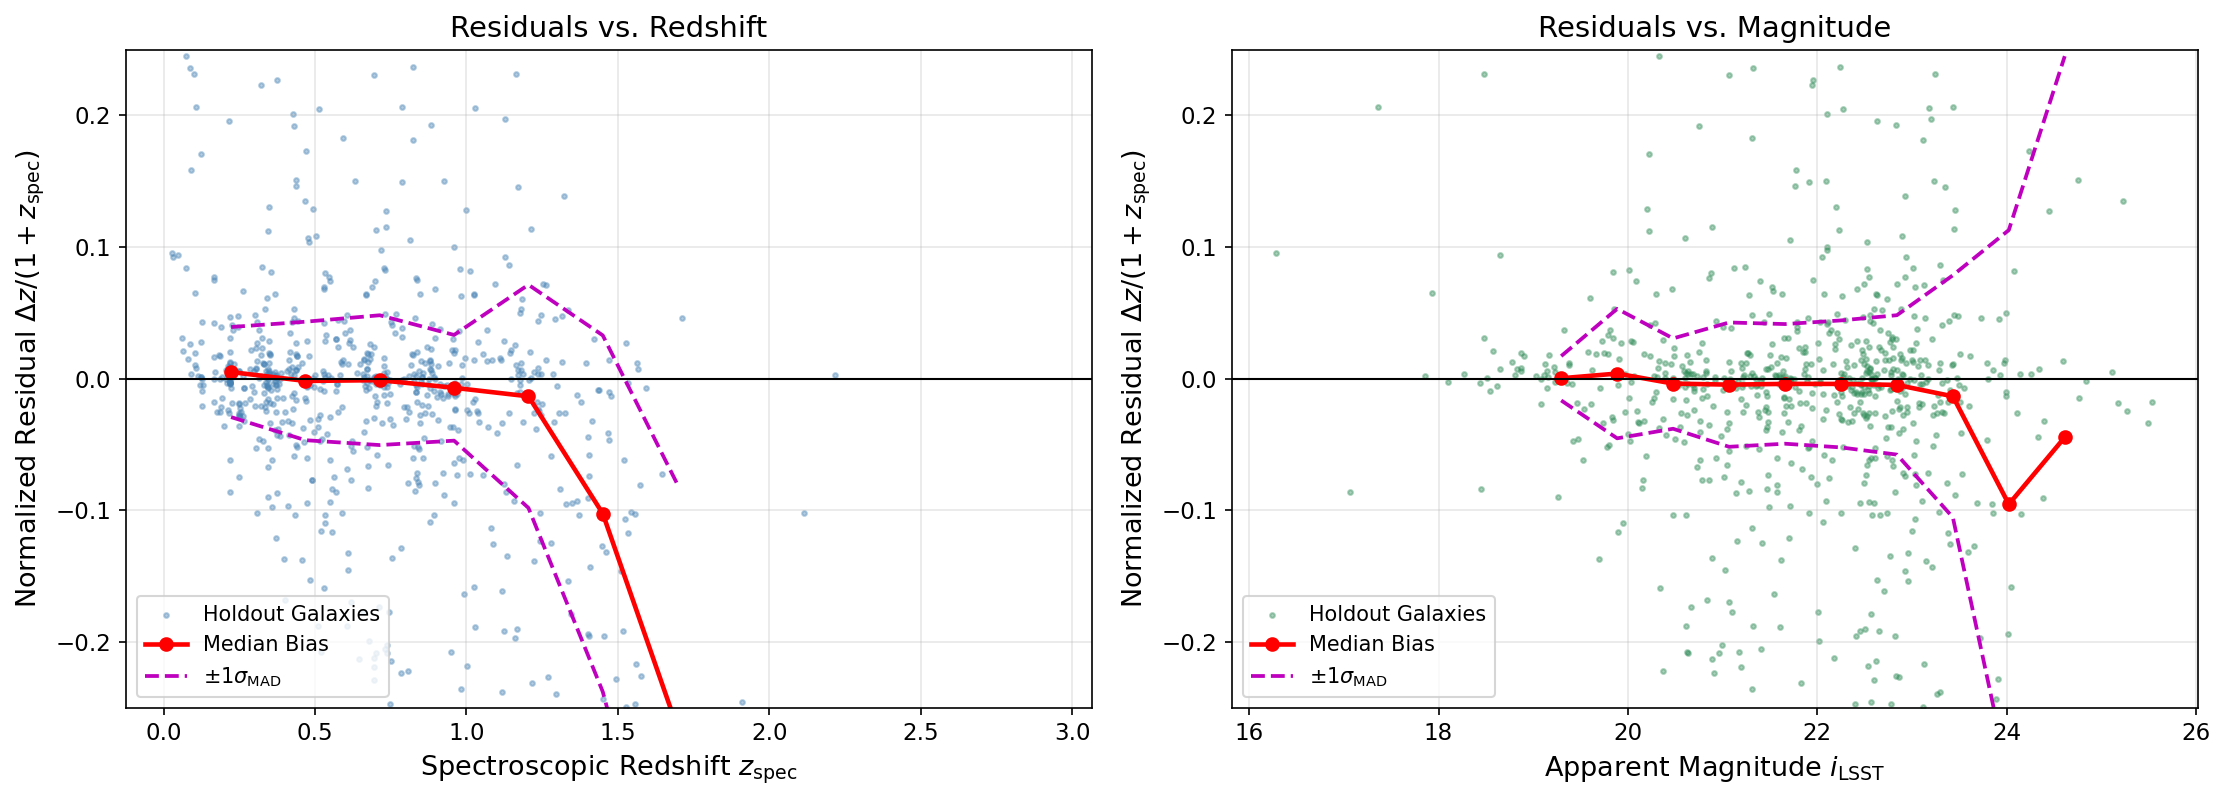

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=150)

dz = metrics_final['residuals']
mag_i_test = te_dict['mag_i_lsst']

# 3A: vs Redshift
ax = axes[0]
ax.scatter(y_test, dz, s=5, color='steelblue', alpha=0.4, label='Holdout Galaxies')
z_bins_eval = np.linspace(0.1, 2.8, 12)
z_bin_cents = 0.5 * (z_bins_eval[:-1] + z_bins_eval[1:])
binned_bias = []
binned_mad = []
for i in range(len(z_bins_eval) - 1):
    m_z = (y_test >= z_bins_eval[i]) & (y_test < z_bins_eval[i+1])
    if np.sum(m_z) > 10:
        b = np.median(dz[m_z])
        binned_bias.append(b)
        binned_mad.append(1.4826 * np.median(np.abs(dz[m_z] - b)))
    else:
        binned_bias.append(np.nan)
        binned_mad.append(np.nan)

ax.plot(z_bin_cents, binned_bias, 'r-o', lw=2.2, label='Median Bias')
ax.plot(z_bin_cents, np.array(binned_bias) + np.array(binned_mad), 'm--', lw=1.8, label=r'$\pm 1\sigma_{\rm MAD}$')
ax.plot(z_bin_cents, np.array(binned_bias) - np.array(binned_mad), 'm--', lw=1.8)
ax.axhline(0, color='black', ls='-', lw=1.0)
ax.set_ylim(-0.25, 0.25)
ax.set_xlabel(r'Spectroscopic Redshift $z_{\rm spec}$')
ax.set_ylabel(r'Normalized Residual $\Delta z / (1 + z_{\rm spec})$')
ax.set_title('Residuals vs. Redshift')
ax.legend(loc='lower left', fontsize=10)

# 3B: vs Magnitude
ax = axes[1]
ax.scatter(mag_i_test, dz, s=5, color='seagreen', alpha=0.4, label='Holdout Galaxies')
mag_bins_eval = np.linspace(19, 25.5, 12)
mag_bin_cents = 0.5 * (mag_bins_eval[:-1] + mag_bins_eval[1:])
b_mag = []
s_mag = []
for i in range(len(mag_bins_eval) - 1):
    m_mag = (mag_i_test >= mag_bins_eval[i]) & (mag_i_test < mag_bins_eval[i+1])
    if np.sum(m_mag) > 10:
        b = np.median(dz[m_mag])
        b_mag.append(b)
        s_mag.append(1.4826 * np.median(np.abs(dz[m_mag] - b)))
    else:
        b_mag.append(np.nan)
        s_mag.append(np.nan)

ax.plot(mag_bin_cents, b_mag, 'r-o', lw=2.2, label='Median Bias')
ax.plot(mag_bin_cents, np.array(b_mag) + np.array(s_mag), 'm--', lw=1.8, label=r'$\pm 1\sigma_{\rm MAD}$')
ax.plot(mag_bin_cents, np.array(b_mag) - np.array(s_mag), 'm--', lw=1.8)
ax.axhline(0, color='black', ls='-', lw=1.0)
ax.set_ylim(-0.25, 0.25)
ax.set_xlabel(r'Apparent Magnitude $i_{\rm LSST}$')
ax.set_ylabel(r'Normalized Residual $\Delta z / (1 + z_{\rm spec})$')
ax.set_title('Residuals vs. Magnitude')
ax.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

### Figures 5 & 6: Probability Integral Transform (PIT) Diagnostics
Tests the statistical calibration and uniformity of the output probability distributions.

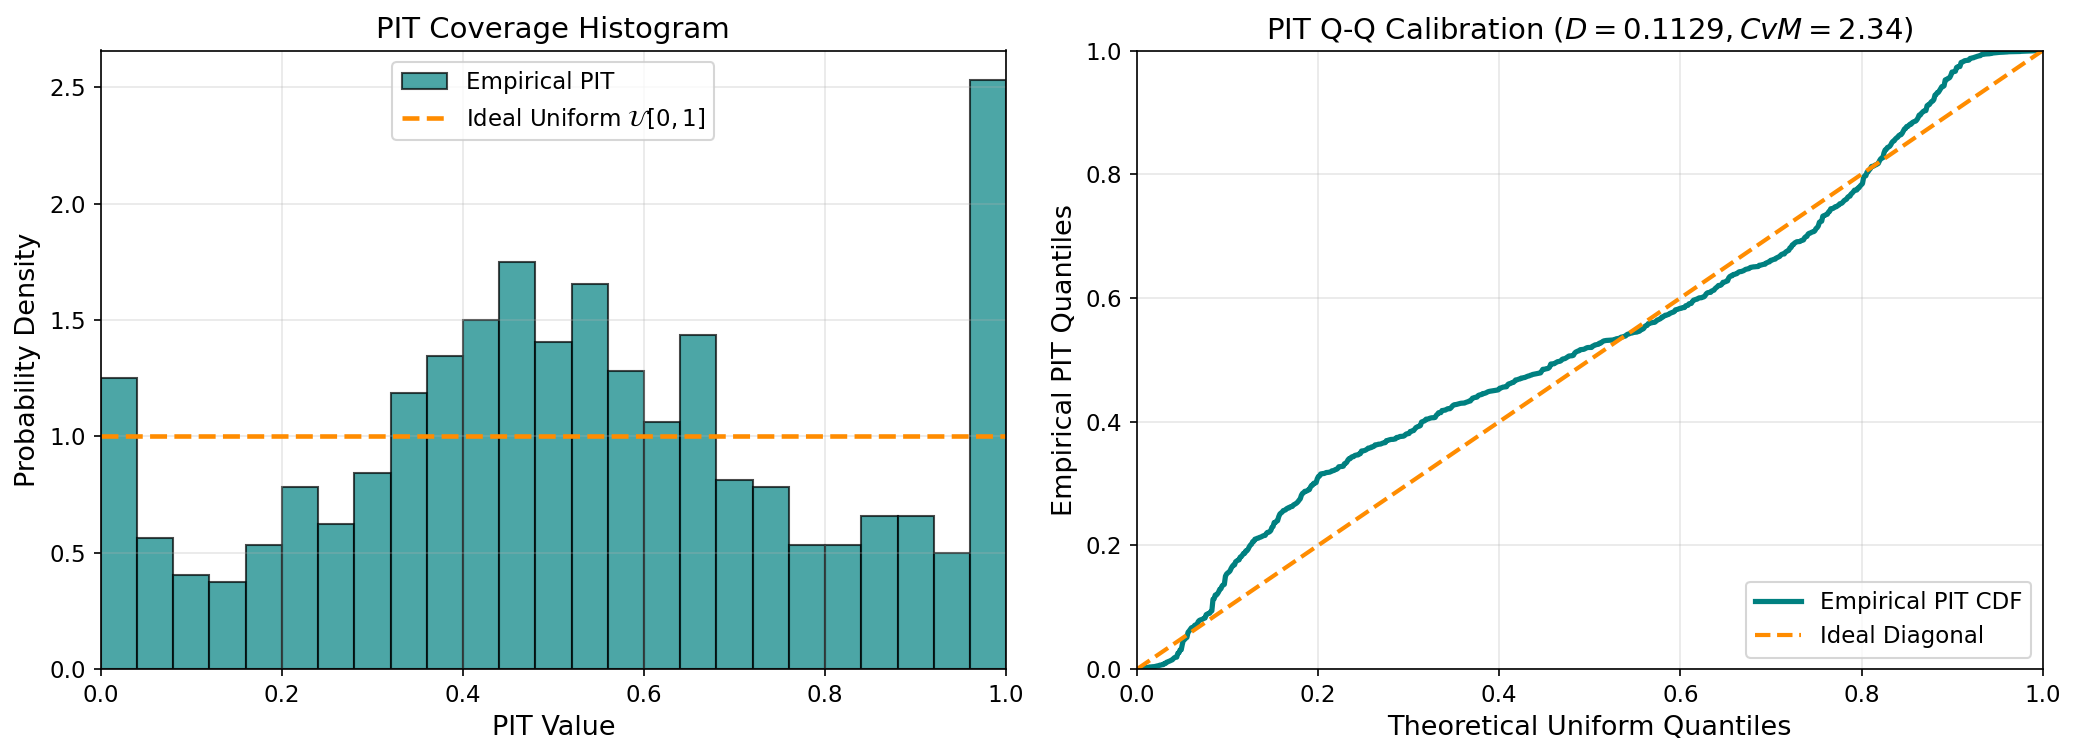

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), dpi=150)

pit = metrics_final['pit_values']

# PIT Histogram
ax = axes[0]
ax.hist(pit, bins=25, density=True, color='teal', alpha=0.7, edgecolor='black', label='Empirical PIT')
ax.axhline(1.0, color='darkorange', ls='--', lw=2.2, label=r'Ideal Uniform $\mathcal{U}[0, 1]$')
ax.set_xlim(0, 1)
ax.set_xlabel('PIT Value')
ax.set_ylabel('Probability Density')
ax.set_title('PIT Coverage Histogram')
ax.legend(loc='upper center')

# PIT QQ-Plot
ax = axes[1]
sorted_pit = np.sort(pit)
uniform_quantiles = np.linspace(0, 1, len(sorted_pit))
ax.plot(uniform_quantiles, sorted_pit, color='teal', lw=2.5, label='Empirical PIT CDF')
ax.plot([0, 1], [0, 1], color='darkorange', ls='--', lw=2.0, label='Ideal Diagonal')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Theoretical Uniform Quantiles')
ax.set_ylabel('Empirical PIT Quantiles')
ax.set_title(rf'PIT Q-Q Calibration ($D={metrics_final["PIT KS Statistic"]:.4f}, CvM={metrics_final["Cramer-von Mises (CvM)"]:.2f}$)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Figure 7: Reconstructed Ensemble Redshift Distribution $n(z)$
Stacked posterior distribution compared directly with the true spectroscopic distribution $N(z_{\rm spec})$ with residual difference panel.

/tmp/ipykernel_494461/3944768768.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


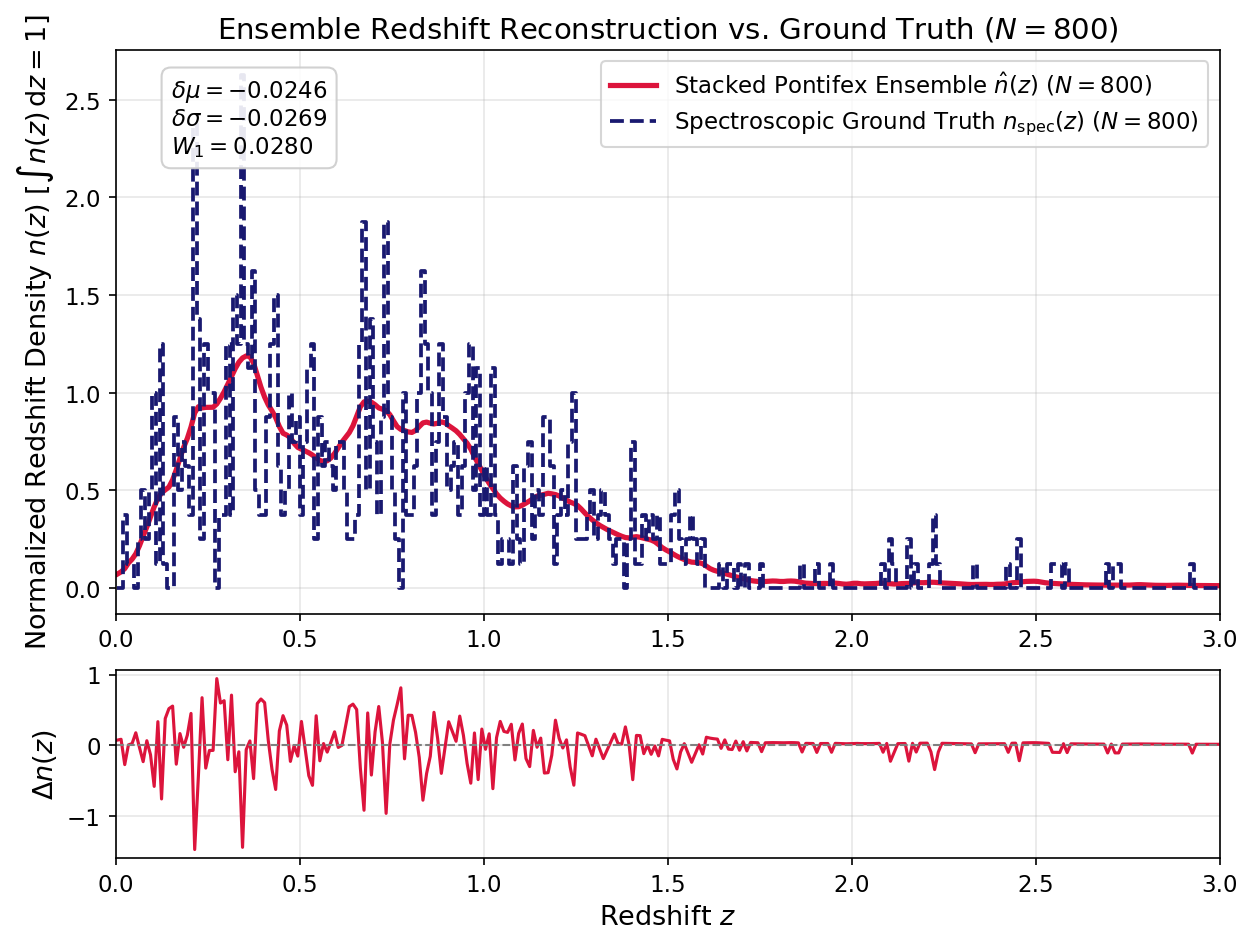

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 7.0), dpi=150, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.15})

dz_grid = Z_CENTERS[1] - Z_CENTERS[0]
stacked_nz = np.mean(pdf_calibrated, axis=0)
counts_spec, edges_spec = np.histogram(y_test, bins=len(Z_CENTERS), range=(Z_CENTERS[0]-0.5*dz_grid, Z_CENTERS[-1]+0.5*dz_grid), density=True)

ax1.plot(Z_CENTERS, stacked_nz, color='crimson', lw=2.5, label=rf'Stacked Pontifex Ensemble $\hat{{n}}(z)$ ($N={len(y_test):,}$)')
ax1.step(Z_CENTERS, counts_spec, where='mid', color='midnightblue', lw=1.8, ls='--', label=rf'Spectroscopic Ground Truth $n_{{\rm spec}}(z)$ ($N={len(y_test):,}$)')
ax1.set_xlim(0, 3)
ax1.set_ylabel(r'Normalized Redshift Density $n(z)\ [\int n(z)\,\mathrm{d}z = 1]$')
ax1.set_title(rf'Ensemble Redshift Reconstruction vs. Ground Truth ($N={len(y_test):,}$)')
ax1.legend(loc='upper right')

stat_box = (
    rf"$\delta\mu = {metrics_final['Delta_mu (DESC SRD)']:+.4f}$" + "\n"
    rf"$\delta\sigma = {metrics_final['Delta_sigma (DESC SRD)']:+.4f}$" + "\n"
    rf"$W_1 = {metrics_final['Wasserstein W1']:.4f}$"
)
ax1.text(0.05, 0.95, stat_box, transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='#ccc'))

# Residual panel
diff_nz = stacked_nz - counts_spec
ax2.plot(Z_CENTERS, diff_nz, color='crimson', lw=1.5)
ax2.axhline(0.0, color='gray', ls='--', lw=1.0)
ax2.set_xlim(0, 3)
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'$\Delta n(z)$')

plt.tight_layout()
plt.show()

## 12. Exporting Tutorial Predictions & Calibrated PDFs
We export the final calibrated predictions table and continuous PDF arrays to `results/tutorial_predictions/`.

In [17]:
output_dir = repo_root / "results" / "tutorial_predictions"
output_dir.mkdir(parents=True, exist_ok=True)

results_df = pd.DataFrame({
    'object_id': te_dict['object_id'],
    'ra': te_dict['ra'],
    'dec': te_dict['dec'],
    'z_spec': y_test,
    'z_mode_moe': z_mode_moe,
    'z_mode_final': z_mode_final,
    'dz_final': (z_mode_final - y_test) / (1.0 + y_test),
    'is_blend_candidate': is_blend_candidate,
})

csv_path = output_dir / "pontifex_tutorial_predictions.csv"
npz_path = output_dir / "pontifex_tutorial_pdfs.npz"

results_df.to_csv(csv_path, index=False)
np.savez_compressed(
    npz_path,
    z_grid=Z_CENTERS,
    pdfs_moe=pdf_moe,
    pdfs_calib=pdf_calibrated,
    object_id=te_dict['object_id'],
    z_spec=y_test
)

print(f"✓ Saved tutorial predictions table to: {csv_path} ({len(results_df):,} rows)")
print(f"✓ Saved tutorial continuous PDFs to:   {npz_path}")

✓ Saved tutorial predictions table to: /media/mardom/Backup/Rubin-LSST-Research/Photometric-Redshift/code/DDFpz/results/tutorial_predictions/pontifex_tutorial_predictions.csv (800 rows)
✓ Saved tutorial continuous PDFs to:   /media/mardom/Backup/Rubin-LSST-Research/Photometric-Redshift/code/DDFpz/results/tutorial_predictions/pontifex_tutorial_pdfs.npz
